
# Notebook 03 — NLP TF-IDF + Ridge Regression Baseline

This notebook uses **only the cleaned datasets produced by Notebook 02**.

## Goal

Build the first reproducible ML baseline using:

- Word-level TF-IDF
- Character-level TF-IDF
- Combined Word + Character TF-IDF
- Ridge Regression
- `log1p(PRODUCT_LENGTH)` target transformation
- MAPE as the primary metric

**Leakage rule:** TF-IDF is fitted only on the training split. Validation and test are transformed using that fitted vocabulary.


## 0. Configuration

In [1]:
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

CLEAN_DIR = "../dataset/cleaned"

TRAIN_FILE = os.path.join(CLEAN_DIR, "train_clean_debug.csv")
TEST_FILE = os.path.join(CLEAN_DIR, "test_clean_debug.csv")

ARTIFACT_DIR = "../artifacts/notebook_03"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

VALID_SIZE = 0.20
RANDOM_STATE = 42

WORD_NGRAM_RANGE = (1, 2)
WORD_MIN_DF = 2
WORD_MAX_DF = 0.98
WORD_MAX_FEATURES = 200_000

CHAR_NGRAM_RANGE = (3, 5)
CHAR_MIN_DF = 2
CHAR_MAX_DF = 0.995
CHAR_MAX_FEATURES = 150_000

RIDGE_ALPHA = 10.0
USE_LOG_TARGET = True
PREDICTION_MIN = 1e-6

print("Configuration loaded.")


Configuration loaded.


## 1. Load cleaned datasets

In [2]:

train = pd.read_csv(TRAIN_FILE)
test = pd.read_csv(TEST_FILE)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head(3))


Train shape: (48484, 27)
Test shape : (10000, 26)


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH,DIM_1_CM,DIM_2_CM,DIM_3_CM,DIM_COUNT,DIM_PRODUCT_2D_CM2,DIM_VOLUME_CM3,HAS_DIMENSION_2D,HAS_DIMENSION_3D,TITLE_CHAR_COUNT,TITLE_WORD_COUNT,TITLE_DIGIT_COUNT,TITLE_EMPTY,BULLET_CHAR_COUNT,BULLET_WORD_COUNT,BULLET_DIGIT_COUNT,BULLET_EMPTY,DESC_CHAR_COUNT,DESC_WORD_COUNT,DESC_DIGIT_COUNT,DESC_EMPTY,HAS_MEASUREMENT_UNIT
0,2028640,WHICHWOOD Wooden Handmade Ashok Stamb with Clock and Flag Desk Organizer for Office and Home Dec...,Purely high material |Ashok Stambh will definitely going to amuse your guests and visitors and w...,"Wooden Ashoka pillar- National Emblem-Ashoka Stambh. Size: Height: 8"" Hand carved & Best quality...",8271,300.0,10.00,10.00,38.100,0,100.0000,3810.000000,0,0,111,17,0,0,195,34,0,0,599,101,2,0,1
1,1369397,"Red and Black Throw Pillow Cushion Cover by Ambesonne, Poppy Field Spring Time Flower Grass Open...",[18 INCHES x 18 INCHES - DOUBLE SIDED PRINT - With Zipper. Cut and sewn by hand. INSERT NOT INCL...,Makeover and refresh your rooms with just a single touch! Start with these fun and decorative cu...,10324,1080.0,45.72,45.72,9.652,2,2090.3184,20175.753197,1,0,196,33,4,0,479,79,7,0,1475,235,2,0,1
2,462899,Lives that Made Greek History,NaN,NaN,12482,550.0,15.20,22.00,9.652,0,334.4000,3227.628800,0,0,29,5,0,0,0,0,0,1,0,0,0,1,0


## 2. Validate Notebook 02 output

In [3]:

required_train = [
    "PRODUCT_ID", "TITLE", "BULLET_POINTS",
    "DESCRIPTION", "PRODUCT_TYPE_ID", "PRODUCT_LENGTH"
]

required_test = [
    "PRODUCT_ID", "TITLE", "BULLET_POINTS",
    "DESCRIPTION", "PRODUCT_TYPE_ID"
]

for col in required_train:
    assert col in train.columns, f"Missing train column: {col}"

for col in required_test:
    assert col in test.columns, f"Missing test column: {col}"

assert "PRODUCT_LENGTH" not in test.columns
assert train["PRODUCT_ID"].is_unique
assert test["PRODUCT_ID"].is_unique
assert train["PRODUCT_LENGTH"].notna().all()
assert np.isfinite(train["PRODUCT_LENGTH"]).all()
assert (train["PRODUCT_LENGTH"] > 0).all()

print("Clean-data validation PASSED.")
display(train["PRODUCT_LENGTH"].describe())


Clean-data validation PASSED.


count    48484.000000
mean      1044.652274
std       1279.206405
min         54.000000
25%        531.496062
50%        669.291338
75%       1067.222809
max      10200.000000
Name: PRODUCT_LENGTH, dtype: float64

## 3. Build NLP text

In [4]:

TEXT_COLS = ["TITLE", "BULLET_POINTS", "DESCRIPTION"]

def build_text(df):
    text = (
        df["TITLE"].fillna("").astype(str) + " " +
        df["BULLET_POINTS"].fillna("").astype(str) + " " +
        df["DESCRIPTION"].fillna("").astype(str)
    )
    return text.str.replace(r"\s+", " ", regex=True).str.strip()

train["NLP_TEXT"] = build_text(train)
test["NLP_TEXT"] = build_text(test)

display(train[["TITLE", "NLP_TEXT"]].head(5))


,TITLE,NLP_TEXT
0,WHICHWOOD Wooden Handmade Ashok Stamb with Clock and Flag Desk Organizer for Office and Home Dec...,WHICHWOOD Wooden Handmade Ashok Stamb with Clock and Flag Desk Organizer for Office and Home Dec...
1,"Red and Black Throw Pillow Cushion Cover by Ambesonne, Poppy Field Spring Time Flower Grass Open...","Red and Black Throw Pillow Cushion Cover by Ambesonne, Poppy Field Spring Time Flower Grass Open..."
2,Lives that Made Greek History,Lives that Made Greek History
3,"POPINJAY Girls’ Spaghetti Strap Cami Summer Dress for Toddlers and Big Kids, Feels Soft and Look...","POPINJAY Girls’ Spaghetti Strap Cami Summer Dress for Toddlers and Big Kids, Feels Soft and Look..."
4,"Moen 8370HD Commercial PosiTemp Pressure Balancing Shower Valve, 1/2-Inch CC","Moen 8370HD Commercial PosiTemp Pressure Balancing Shower Valve, 1/2-Inch CC [1/2-inch CC connec..."


## 4. Train / validation split

In [5]:

indices = np.arange(len(train))

train_idx, valid_idx = train_test_split(
    indices,
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE
)

train_part = train.iloc[train_idx].copy()
valid_part = train.iloc[valid_idx].copy()

print("Training rows  :", len(train_part))
print("Validation rows:", len(valid_part))


Training rows  : 38787
Validation rows: 9697


## 5. Evaluation functions

In [6]:

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true != 0)

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0


def evaluate_model(name, y_true, y_pred):
    y_pred = np.maximum(np.asarray(y_pred, dtype=np.float64), PREDICTION_MIN)

    result = {
        "model": name,
        "MAPE": mape(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

    print(f"\n{name}")
    print("-" * len(name))
    print(f"MAPE : {result['MAPE']:.4f}%")
    print(f"MAE  : {result['MAE']:.4f}")
    print(f"RMSE : {result['RMSE']:.4f}")

    return result, y_pred


## 6. Prepare target

In [7]:

y_train_raw = train_part["PRODUCT_LENGTH"].astype(np.float64).values
y_valid_raw = valid_part["PRODUCT_LENGTH"].astype(np.float64).values

if USE_LOG_TARGET:
    y_train = np.log1p(y_train_raw)
else:
    y_train = y_train_raw

print("Target:", "log1p(PRODUCT_LENGTH)" if USE_LOG_TARGET else "raw PRODUCT_LENGTH")


Target: log1p(PRODUCT_LENGTH)


## 7. Word-level TF-IDF

In [8]:

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=WORD_NGRAM_RANGE,
    min_df=WORD_MIN_DF,
    max_df=WORD_MAX_DF,
    max_features=WORD_MAX_FEATURES,
    sublinear_tf=True,
    lowercase=True,
    strip_accents="unicode",
    dtype=np.float32
)

X_train_word = word_vectorizer.fit_transform(train_part["NLP_TEXT"])
X_valid_word = word_vectorizer.transform(valid_part["NLP_TEXT"])
X_test_word = word_vectorizer.transform(test["NLP_TEXT"])

print("Word TF-IDF")
print("Train:", X_train_word.shape)
print("Valid:", X_valid_word.shape)
print("Test :", X_test_word.shape)
print("Train non-zero values:", X_train_word.nnz)


Word TF-IDF
Train: (38787, 200000)
Valid: (9697, 200000)
Test : (10000, 200000)
Train non-zero values: 4914926


## 8. Ridge + Word TF-IDF

In [9]:

ridge_word = Ridge(alpha=RIDGE_ALPHA, solver="lsqr")
ridge_word.fit(X_train_word, y_train)

pred_word_model = ridge_word.predict(X_valid_word)
pred_word = np.expm1(pred_word_model) if USE_LOG_TARGET else pred_word_model

word_result, pred_word = evaluate_model(
    "Ridge + Word TF-IDF",
    y_valid_raw,
    pred_word
)



Ridge + Word TF-IDF
-------------------
MAPE : 56.3653%
MAE  : 467.9376
RMSE : 1092.4555


## 9. Character-level TF-IDF

In [10]:

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=CHAR_NGRAM_RANGE,
    min_df=CHAR_MIN_DF,
    max_df=CHAR_MAX_DF,
    max_features=CHAR_MAX_FEATURES,
    sublinear_tf=True,
    dtype=np.float32
)

X_train_char = char_vectorizer.fit_transform(train_part["NLP_TEXT"])
X_valid_char = char_vectorizer.transform(valid_part["NLP_TEXT"])
X_test_char = char_vectorizer.transform(test["NLP_TEXT"])

print("Character TF-IDF")
print("Train:", X_train_char.shape)
print("Valid:", X_valid_char.shape)
print("Test :", X_test_char.shape)
print("Train non-zero values:", X_train_char.nnz)


Character TF-IDF
Train: (38787, 150000)
Valid: (9697, 150000)
Test : (10000, 150000)
Train non-zero values: 47282437


## 10. Ridge + Character TF-IDF

In [11]:

ridge_char = Ridge(alpha=RIDGE_ALPHA, solver="lsqr")
ridge_char.fit(X_train_char, y_train)

pred_char_model = ridge_char.predict(X_valid_char)
pred_char = np.expm1(pred_char_model) if USE_LOG_TARGET else pred_char_model

char_result, pred_char = evaluate_model(
    "Ridge + Character TF-IDF",
    y_valid_raw,
    pred_char
)



Ridge + Character TF-IDF
------------------------
MAPE : 56.8705%
MAE  : 469.6317
RMSE : 1083.9846


## 11. Combine Word + Character TF-IDF

In [12]:

X_train_tfidf = sparse.hstack(
    [X_train_word, X_train_char],
    format="csr"
)

X_valid_tfidf = sparse.hstack(
    [X_valid_word, X_valid_char],
    format="csr"
)

X_test_tfidf = sparse.hstack(
    [X_test_word, X_test_char],
    format="csr"
)

print("Combined TF-IDF")
print("Train:", X_train_tfidf.shape)
print("Valid:", X_valid_tfidf.shape)
print("Test :", X_test_tfidf.shape)


Combined TF-IDF
Train: (38787, 350000)
Valid: (9697, 350000)
Test : (10000, 350000)


## 12. Ridge + Combined TF-IDF

In [13]:

ridge_tfidf = Ridge(alpha=RIDGE_ALPHA, solver="lsqr")
ridge_tfidf.fit(X_train_tfidf, y_train)

pred_tfidf_model = ridge_tfidf.predict(X_valid_tfidf)
pred_tfidf = np.expm1(pred_tfidf_model) if USE_LOG_TARGET else pred_tfidf_model

tfidf_result, pred_tfidf = evaluate_model(
    "Ridge + Word + Character TF-IDF",
    y_valid_raw,
    pred_tfidf
)



Ridge + Word + Character TF-IDF
-------------------------------
MAPE : 54.5737%
MAE  : 451.7689
RMSE : 1038.2189


## 13. Compare the three NLP baselines

In [14]:

results = pd.DataFrame([
    word_result,
    char_result,
    tfidf_result
]).sort_values("MAPE").reset_index(drop=True)

display(results)


,model,MAPE,MAE,RMSE
0,Ridge + Word + Character TF-IDF,54.573745,451.768904,1038.218938
1,Ridge + Word TF-IDF,56.365338,467.937637,1092.455480
2,Ridge + Character TF-IDF,56.870485,469.631702,1083.984610


## 14. MAPE by target range

In [15]:

def mape_by_target_range(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.maximum(np.asarray(y_pred), PREDICTION_MIN)

    ranges = [
        ("54-100", 54, 100),
        ("101-200", 101, 200),
        ("201-500", 201, 500),
        ("501-1000", 501, 1000),
        ("1001-2000", 1001, 2000),
        ("2001-5000", 2001, 5000),
        ("5001+", 5001, np.inf)
    ]

    rows = []

    for label, low, high in ranges:
        mask = (y_true >= low) & (y_true <= high)

        if mask.sum() == 0:
            continue

        rows.append({
            "range": label,
            "count": int(mask.sum()),
            "percentage": float(mask.mean() * 100),
            "MAPE": float(mape(y_true[mask], y_pred[mask]))
        })

    return pd.DataFrame(rows)

range_results = mape_by_target_range(y_valid_raw, pred_tfidf)
display(range_results)


,range,count,percentage,MAPE
0,54-100,207,2.134681,591.771428
1,101-200,327,3.372177,272.428402
2,201-500,1682,17.345571,70.205561
3,501-1000,4892,50.448592,18.826088
4,1001-2000,1808,18.644942,33.522107
5,2001-5000,518,5.341858,56.033807
6,5001+,263,2.712179,67.697249


## 15. Actual vs predicted

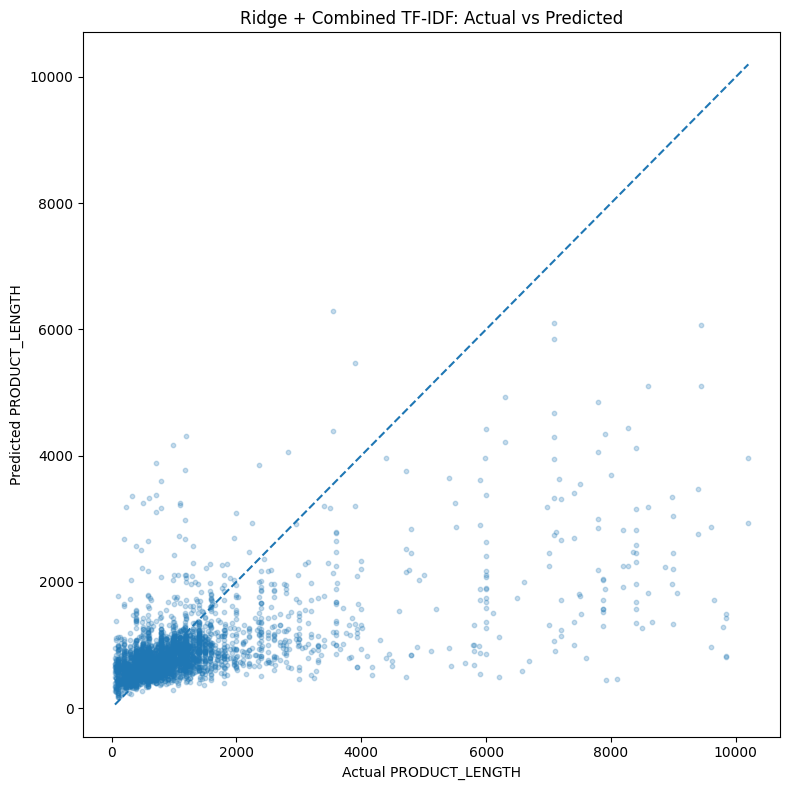

In [16]:

sample_size = min(5000, len(y_valid_raw))
rng = np.random.default_rng(RANDOM_STATE)

sample_idx = rng.choice(
    len(y_valid_raw),
    size=sample_size,
    replace=False
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    y_valid_raw[sample_idx],
    pred_tfidf[sample_idx],
    alpha=0.25,
    s=10
)

low = min(y_valid_raw[sample_idx].min(), pred_tfidf[sample_idx].min())
high = max(y_valid_raw[sample_idx].max(), pred_tfidf[sample_idx].max())

ax.plot([low, high], [low, high], linestyle="--")

ax.set_xlabel("Actual PRODUCT_LENGTH")
ax.set_ylabel("Predicted PRODUCT_LENGTH")
ax.set_title("Ridge + Combined TF-IDF: Actual vs Predicted")

plt.tight_layout()
plt.show()


## 16. Inspect worst validation errors

In [17]:

error_df = valid_part[
    ["PRODUCT_ID", "TITLE", "PRODUCT_TYPE_ID", "PRODUCT_LENGTH"]
].copy()

error_df["prediction"] = pred_tfidf
error_df["absolute_error"] = (
    np.abs(error_df["PRODUCT_LENGTH"] - error_df["prediction"])
)

error_df["APE"] = (
    error_df["absolute_error"] /
    error_df["PRODUCT_LENGTH"]
) * 100

display(error_df.sort_values("APE", ascending=False).head(50))


,PRODUCT_ID,TITLE,PRODUCT_TYPE_ID,PRODUCT_LENGTH,prediction,absolute_error,APE
6605,1853847,"Erosebridal Hip Hop Bedding Set, Cute Cartoon Image Comforter Cover, Colorful Bedspread Cover, L...",12090,120.000000,3297.266846,3177.266846,2647.722371
16115,2044746,Round Hanging Mirrors Wall Decor - Vanity Mounted Wall Mirror with Metal Frame for Contemporary ...,1588,100.000000,1783.314697,1683.314697,1683.314697
34682,2184898,Hemden Embroidered Brown Set of 2 Dupion Silk Cushion Covers 30x30 cm,7256,78.740157,1380.432007,1301.691849,1653.148650
6312,2861203,"Gold and Colorful Abstract Art Throw Pillow Covers, Set of 4 Modern Painting Decorative Pillowca...",7256,100.000000,1739.472046,1639.472046,1639.472046
43251,2695120,"KRAVETTO Quick Grip Clamps 150mm (6""), Heavy Duty Bar Clamps/Spreader, One Handed Bar Clamps, Qu...",9745,55.118000,946.177979,891.059979,1616.640623
25652,2000461,"KZEMATLI Bigfoot I Want to Believe Oven Mitts and Pot Holders Sets, Soft Cotton Lining with Non-...",1345,71.000000,1074.541382,1003.541382,1413.438566
18673,2955239,Nutcase Foldable Wooden Lapdesk Breakfast Bed Table - Evil Eye Protector,5503,78.740157,1108.252563,1029.512406,1307.480757
1388,2653723,"Dee's Collection 800 Thread Count Luxurious Bed Quilt, Duvet, Rajai, Blanket Cover with Zipper- ...",1623,236.220472,3193.284912,2957.064440,1251.823948
29633,1415441,Casual Nights Women's Long Quilted Robe House Dress - Mint Rust - Small,2986,100.000000,1347.189941,1247.189941,1247.189941
46280,1454143,Celine Linen Luxury Silky Soft Coziest 1500 Thread Count Egyptian Quality 2-Piece Duvet Cover Se...,1619,200.000000,2674.303223,2474.303223,1237.151611


## 17. Save validation predictions

In [18]:

validation_predictions = valid_part[
    ["PRODUCT_ID", "PRODUCT_TYPE_ID", "PRODUCT_LENGTH"]
].copy()

validation_predictions["prediction"] = pred_tfidf
validation_predictions["APE"] = (
    np.abs(
        validation_predictions["PRODUCT_LENGTH"]
        - validation_predictions["prediction"]
    )
    / validation_predictions["PRODUCT_LENGTH"]
) * 100

PREDICTION_FILE = os.path.join(
    ARTIFACT_DIR,
    "validation_predictions_ridge_tfidf.csv"
)

validation_predictions.to_csv(PREDICTION_FILE, index=False)

print("Saved:", PREDICTION_FILE)


Saved: ../artifacts/notebook_03\validation_predictions_ridge_tfidf.csv


## 18. Save models and vectorizers

In [19]:

joblib.dump(
    word_vectorizer,
    os.path.join(ARTIFACT_DIR, "word_tfidf_vectorizer.joblib")
)

joblib.dump(
    char_vectorizer,
    os.path.join(ARTIFACT_DIR, "char_tfidf_vectorizer.joblib")
)

joblib.dump(
    ridge_word,
    os.path.join(ARTIFACT_DIR, "ridge_word_tfidf.joblib")
)

joblib.dump(
    ridge_char,
    os.path.join(ARTIFACT_DIR, "ridge_char_tfidf.joblib")
)

joblib.dump(
    ridge_tfidf,
    os.path.join(ARTIFACT_DIR, "ridge_combined_tfidf.joblib")
)

print("Artifacts saved to:", ARTIFACT_DIR)


Artifacts saved to: ../artifacts/notebook_03


## 19. Save experiment configuration

In [20]:

config = {
    "train_file": TRAIN_FILE,
    "test_file": TEST_FILE,
    "validation_size": VALID_SIZE,
    "random_state": RANDOM_STATE,
    "use_log_target": USE_LOG_TARGET,
    "word_ngram_range": list(WORD_NGRAM_RANGE),
    "word_min_df": WORD_MIN_DF,
    "word_max_df": WORD_MAX_DF,
    "word_max_features": WORD_MAX_FEATURES,
    "char_ngram_range": list(CHAR_NGRAM_RANGE),
    "char_min_df": CHAR_MIN_DF,
    "char_max_df": CHAR_MAX_DF,
    "char_max_features": CHAR_MAX_FEATURES,
    "ridge_alpha": RIDGE_ALPHA,
    "results": results.to_dict(orient="records")
}

CONFIG_FILE = os.path.join(ARTIFACT_DIR, "experiment_config.json")

with open(CONFIG_FILE, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("Saved:", CONFIG_FILE)


Saved: ../artifacts/notebook_03\experiment_config.json



# Notebook 03 Complete

The first NLP baselines are:

1. Ridge + Word TF-IDF
2. Ridge + Character TF-IDF
3. Ridge + Word + Character TF-IDF

Record the MAPE from the comparison table.

The next improvement will combine the NLP representation with the structured features created in Notebook 02:

- dimension features
- `PRODUCT_TYPE_ID`
- text statistics
- dimension-presence flags

Then we can move from the Ridge baseline toward LightGBM/CatBoost/XGBoost.
